# Do symbol hints help model agreement checks? — Candidate-Signature Consensus (CSC) demo

This notebook is a runnable walkthrough of the iteration-4 **T6-P** experiment on **Candidate-Signature Consensus (CSC)**. CSC is a gold-free faithfulness check for natural-language → first-order-logic (NL→FOL) translations.

**The idea.** Given a sentence and a candidate FOL formula, *k = 3* peer models from other families (deepseek-v3.2, phi-4, gpt-4.1-mini; qwen3-235b is added for K4) translate the same sentence. They are **cued with the candidate's own symbol list** (name/arity). A peer *agrees* when its formula is **exactly z3-equivalent** to the candidate once predicate and constant names are lower-cased. No symbol aligner is used.

`c_csc = 1 − agree / used`. A higher score means the candidate is more likely an ERROR, and it is flagged when `c > 0.5`.

**What actually ran (deviation D-BUDGET).** The run-wide OpenRouter budget was used up before the first CSC peer call, so no *own-signature* CSC peers exist. The gates G3-P (rename false alarms), G4 (anchoring) and MT (typing on E) are therefore **untested**, not failed. The zero-cost arms were measured instead. The headline arm is **SIGPROXY**: signature-cued outputs of the same four families, taken from exp 7 and cued with the closed *template* signature on the R_COMP bases. It is compared against **FREE3**, the uncued few-shot outputs of the same three families.

**What this demo reproduces.** The original `method.py` is a stage orchestrator that shells out to `src/*.py`. Below we:
1. show the orchestrator (dry run: the API stages are skipped exactly as in the run);
2. inline the exact-equivalence core the stages call: the FOL parser → z3, `csc_lib.consensus_score` / `peer_majority`, and the `csc_score.score_task` logic;
3. score a curated **R_COMP subset** (20 sentences: 20 correct bases, 59 mutants, 21 meaning-preserving controls) with SIGPROXY and FREE3 peers;
4. compute the paper's quantities: mutant recall per operator, false-alarm rate **d** on correct bases (cued vs uncued), and control false alarms / flips. We then check the recomputed scores against the scores the original pipeline wrote.

Full-run reference numbers (74 long R_COMP bases): d = **0.149** cued (SIGPROXY K3) vs **0.757** uncued FREE3-ALIGN; recall on 1,196 mutants **1.000**; rename FA **1.000** under a base-signature cue.

In [1]:
%%capture
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# z3-solver, loguru — NOT pre-installed on Colab, always install
_pip('z3-solver==5.1.0.0', 'loguru==0.7.3')

# numpy, pandas, matplotlib — pre-installed on Colab, install locally only (at Colab's versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')

## Imports
The first block is `method.py`'s original import block. The second block adds what the inlined library code needs (`z3`, `hashlib`, `random`, `re`, …) and the analysis/plotting libraries.

In [2]:
# --- original method.py imports ---
from __future__ import annotations

import argparse
import asyncio
import subprocess
import sys
from pathlib import Path

from loguru import logger

# --- additional imports for the inlined library code (csc_lib / vendor_e.fol / peer_text / repair_census) and the demo ---
import hashlib
import itertools
import json
import random
import re
import time
from collections import defaultdict
from types import SimpleNamespace

import z3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.setrecursionlimit(20000)  # as in peer_text.py (deeply nested formulas)

## Data loading
`mini_demo_data.json` is loaded from GitHub (Colab), falling back to a local copy. It contains:
* `sentences[sentence_id]` → `sigproxy_peers` (model → `{fol, alt_fol}`, the exp-7 SIG outputs of the 4 peer families) and `free3_peers` (slots G4/G6/G7 = deepseek / phi-4 / gpt-4.1-mini uncued outputs);
* `examples` → one row per candidate: `text`, `candidate_fol`, `fold` (BASE / PERTURB / PERTURB_CONTROL), `op_label` (error or control type), `y` (1 = ERROR), complexity strata, and `orig_scores` (what the original run wrote to `results/scores_raw.jsonl`).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_e4aqYfQhdCkX/round-4/experiment-10/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["description"])
print(f"{len(data['sentences'])} sentences, {len(data['examples'])} candidate rows")

20 R_COMP sentences (spread over the word-length range): their correct BASE row plus 80 mutants / meaning-preserving controls sampled round-robin over operators. Per sentence: SIGPROXY peers (exp-7 SIG outputs of deepseek-v3.2, phi-4, gpt-4.1-mini, qwen3-235b; cued with the template signature) and FREE3 peers (uncued few-shot outputs of the same three families). orig_scores = the scores the original pipeline wrote to results/scores_raw.jsonl.
20 sentences, 100 candidate rows


## Config
All tunable parameters are here. The original run scored **every** PERTURB row (5,402) and SIG row (2,210) with a 2 s z3 timeout per equivalence check. The demo scores the first `N_SENTENCES` sentences of the curated subset, with at most `MAX_ROWS` candidate rows.

In [5]:
N_SENTENCES = 20      # sentences of the subset to score (max 20 in mini_demo_data.json; original: all 77 R_COMP + 200 E bases)
MAX_ROWS = 100        # cap on candidate rows scored (max 100 here; original: 5,402 PERTURB + 2,210 SIG rows)
Z3_MS = 2000          # z3 timeout per equivalence check in ms (original: 2000)
FLAG_AT = 0.5         # a candidate is flagged as ERROR when c > FLAG_AT (original: 0.5)

## The original orchestrator (`method.py`)
This is `method.py` as written. The only change is `ROOT = Path.cwd()`, because a notebook has no `__file__`. Each stage is a `subprocess` call into `src/*.py`. `key_has_budget()` sends a 1-token OpenRouter probe, and the API stages (`pilot`, `peers`) run only when that probe succeeds. In the original run the probe returned `403 aii_run_budget_exhausted`, so both API stages were skipped (deviation D-BUDGET).

We do **not** call `main()` here: `src/` is not shipped with the demo. The stages this demo reproduces (`score`, `analysis`) are inlined in the cells that follow.

In [6]:
ROOT = Path.cwd()  # notebook: was Path(__file__).resolve().parent
PY = sys.executable
(ROOT / "logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")


def run(args: list[str], timeout: int = 7200) -> None:
    logger.info("$ " + " ".join(args))
    r = subprocess.run(args, cwd=ROOT, timeout=timeout)
    if r.returncode != 0:
        raise RuntimeError(f"stage failed ({r.returncode}): {' '.join(args)}")


def key_has_budget() -> bool:
    sys.path.insert(0, str(ROOT / "src"))
    import or_client
    try:
        ok, msg = asyncio.run(or_client.probe())
    except Exception as ex:  # noqa: BLE001 - network errors mean 'no budget now'
        ok, msg = False, f"{type(ex).__name__}: {ex}"
    logger.info(f"key probe: {msg}")
    return ok


STAGES = {
    "views": [[PY, "src/views.py"]],
    "tests": [[PY, "-m", "pytest", "-q", "tests/test_csc_lib.py", "-p", "no:cacheprovider"]],
    "pilot": [[PY, "src/peers_run.py", "pilot"]],
    "prereg": [[PY, "src/csc_prereg.py"]],
    "peers": [[PY, "src/peers_run.py", "all"]],
    "local": [[PY, "src/local_peers.py"]],
    "score": [[PY, "src/csc_score.py"], [PY, "src/csc_score.py", "--local"]],
    "typing": [[PY, "src/csc_typing.py", "--which", "oracle,csc,proxy,free3"]],
    "analysis": [[PY, "src/csc_analysis.py"], [PY, "src/csc_tables.py"]],
    "manifest": [[PY, "src/csc_manifest.py"]],
    "output": [[PY, "src/csc_output.py"]],
    "rederive": [[PY, "tests/rederive.py"]],
}
ORDER = ["views", "tests", "pilot", "prereg", "peers", "local", "score", "typing", "manifest", "analysis", "output", "rederive"]
API = {"pilot", "peers"}


@logger.catch(reraise=True)
def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--stage", default="all")
    a = ap.parse_args()
    stages = ORDER if a.stage == "all" else a.stage.split(",")
    api_ok = None
    for st in stages:
        if st not in STAGES:
            raise SystemExit(f"unknown stage {st}; choose from {ORDER}")
        if st in API:
            if api_ok is None:
                api_ok = key_has_budget()
            if not api_ok:
                logger.warning(f"skipping {st}: OpenRouter key has no budget (deviation D-BUDGET)")
                continue
        for cmd in STAGES[st]:
            run(cmd)
    logger.info("done")

In [7]:
# Dry run of main()'s control flow: print the stage plan, with api_ok = False as in the original run (D-BUDGET)
api_ok = False
for st in ORDER:
    if st in API and not api_ok:
        logger.warning(f"skipping {st}: OpenRouter key has no budget (deviation D-BUDGET)")
        continue
    for cmd in STAGES[st]:
        print(f"[{st:9s}] $ " + " ".join(Path(c).name if c == PY else c for c in cmd))

[views    ] $ python src/views.py
[tests    ] $ python -m pytest -q tests/test_csc_lib.py -p no:cacheprovider
11:47:54|WARNING|skipping pilot: OpenRouter key has no budget (deviation D-BUDGET)


[prereg   ] $ python src/csc_prereg.py
11:47:54|WARNING|skipping peers: OpenRouter key has no budget (deviation D-BUDGET)


[local    ] $ python src/local_peers.py
[score    ] $ python src/csc_score.py
[score    ] $ python src/csc_score.py --local
[typing   ] $ python src/csc_typing.py --which oracle,csc,proxy,free3
[manifest ] $ python src/csc_manifest.py
[analysis ] $ python src/csc_analysis.py
[analysis ] $ python src/csc_tables.py
[output   ] $ python src/csc_output.py
[rederive ] $ python tests/rederive.py


## FOL parser and z3 equivalence (`vendor_e/fol.py`)
Every stage uses the dataset-E parser. It reads Unicode FOL in FOLIO/MALLS notation into a tuple AST (`("all", v, body)`, `("atom", name, args)`, …). It also translates the AST to z3 over an uninterpreted sort `U`, and decides equivalence as **validity of `F1 ↔ F2`** with a timeout. Only the functions CSC uses are copied (unchanged). The monotonicity-profile and glue-check helpers of the original module are omitted.

In [8]:
TOK = re.compile(r"\s*(∀|∃|¬|∧|∨|→|↔|⊕|\(|\)|,|[A-Za-z_][A-Za-z0-9_'\-]*)")
OPS = {"↔": "iff", "⊕": "xor", "→": "imp", "∨": "or", "∧": "and"}
IDENT = re.compile(r"^[A-Za-z_][A-Za-z0-9_'\-]*$")
PREC = {"iff": 1, "imp": 2, "xor": 3, "or": 3, "and": 4}  # FIX (gen_art_dataset_1): ⊕ moved to the ∨ level, binds tighter than →


def tokenize(s: str) -> list[str]:
    s = s.replace("⇒", "→").replace("<->", "↔").replace("->", "→").replace("&", "∧").replace("|", "∨")  # FIX: <-> before ->
    s = s.replace("~", "¬").replace("!", "¬").replace("¬", "¬").replace("−", "-")
    pos, out = 0, []
    s = s.strip().rstrip(".")
    while pos < len(s):
        m = TOK.match(s, pos)
        if not m:
            raise ValueError(f"bad char at {pos}: {s[pos:pos+10]!r}")
        out.append(m.group(1))
        pos = m.end()
        while pos < len(s) and s[pos].isspace():
            pos += 1
    return out


class Parser:
    def __init__(self, s: str):
        self.t = tokenize(s)
        self.i = 0

    def peek(self):
        return self.t[self.i] if self.i < len(self.t) else None

    def eat(self, x=None):
        tok = self.peek()
        if x is not None and tok != x:
            raise ValueError(f"expected {x} got {tok}")
        self.i += 1
        return tok

    def parse(self):
        e = self.expr(0)
        if self.peek() is not None:
            raise ValueError(f"trailing {self.t[self.i:]}")
        return e

    def expr(self, minp):
        lhs = self.unary()
        while self.peek() in OPS and PREC[OPS[self.peek()]] > minp - 1 and PREC[OPS[self.peek()]] >= minp:
            op = OPS[self.eat()]
            # → is right-assoc, others left-assoc
            nxt = PREC[op] if op == "imp" else PREC[op] + 1
            rhs = self.expr(nxt)
            lhs = (op, lhs, rhs)
        return lhs

    def unary(self):
        tok = self.peek()
        if tok == "¬":
            self.eat()
            return ("not", self.unary())
        if tok in ("∀", "∃"):
            self.eat()
            vs = [self.eat()]
            while self.peek() not in ("(", "¬", "∀", "∃") and self.peek() is not None and re.match(r"^[a-z][a-z0-9]*$", self.peek() or "") and not self._is_atom_start():
                vs.append(self.eat())
            body = self.unary()  # FOLIO/MALLS convention: a quantifier binds the next group/atom/quantifier
            for v in reversed(vs):
                body = ("all" if tok == "∀" else "ex", v, body)
            return body
        if tok == "(":
            self.eat("(")
            e = self.expr(0)
            self.eat(")")
            return e
        name = self.eat()
        if name is None or not IDENT.match(name):  # FIX (gen_art_dataset_1): truncated input used to yield atom None
            raise ValueError(f"expected identifier, got {name!r}")
        if self.peek() == "(":
            self.eat("(")
            args = [self.eat()]
            while self.peek() == ",":
                self.eat(",")
                args.append(self.eat())
            self.eat(")")
            if any(a is None or not IDENT.match(a) for a in args):
                raise ValueError(f"bad argument list {args!r}")
            return ("atom", name, tuple(args))
        return ("atom", name, ())  # propositional atom

    def _is_atom_start(self):
        return self.i + 1 < len(self.t) and self.t[self.i + 1] == "("


def fol_parse(s: str):  # vendor_e.fol.parse (renamed only to avoid clashing with csc_lib.parse below)
    return Parser(s).parse()


def preds(e, acc=None):
    acc = {} if acc is None else acc
    if e[0] == "atom":
        acc[f"{e[1]}/{len(e[2])}"] = len(e[2])  # key by name/arity: arity clashes are distinct symbols
    elif e[0] in ("all", "ex"):
        preds(e[2], acc)
    elif e[0] == "not":
        preds(e[1], acc)
    else:
        preds(e[1], acc)
        preds(e[2], acc)
    return acc


U = z3.DeclareSort("U")


def to_z3(e, env, P):
    k = e[0]
    if k in ("all", "ex"):
        v = z3.Const(e[1], U)
        env2 = dict(env)
        env2[e[1]] = v
        b = to_z3(e[2], env2, P)
        return z3.ForAll([v], b) if k == "all" else z3.Exists([v], b)
    if k == "not":
        return z3.Not(to_z3(e[1], env, P))
    if k == "atom":
        args = [env.get(a, z3.Const("c_" + a, U)) for a in e[2]]
        f = P[f"{e[1]}/{len(e[2])}"]
        return f(*args) if args else f
    a, b = to_z3(e[1], env, P), to_z3(e[2], env, P)
    return {"and": lambda: z3.And(a, b), "or": lambda: z3.Or(a, b), "imp": lambda: z3.Implies(a, b),
            "iff": lambda: a == b, "xor": lambda: z3.Xor(a, b)}[k]()


def mkpred(name, n):
    name = name.replace("/", "_a")
    return z3.Function(name, *([U] * n), z3.BoolSort()) if n else z3.Bool(name)


def valid(c, ms=3000):
    s = z3.Solver()
    s.set("timeout", ms)
    s.add(z3.Not(c))
    r = s.check()
    return True if r == z3.unsat else (False if r == z3.sat else None)


def equivalent(e1, e2, ms=5000):
    ar = {**preds(e1), **preds(e2)}
    P = {q: mkpred(q, m) for q, m in ar.items()}
    return valid(to_z3(e1, {}, P) == to_z3(e2, {}, P), ms)


EFOL = SimpleNamespace(parse=fol_parse, preds=preds, to_z3=to_z3, equivalent=equivalent)

## Canonical strings and random-model fingerprints (`peer_text` / `repair_census`)
`csc_lib.prep()` needs three helpers, copied unchanged:
* `PT.canon`: renames bound variables to `v0, v1, …` and prints the result. Identical canonical strings mean the formulas are equivalent at once, without calling z3.
* `RC.fp`: evaluates the formula in 24 pseudo-random models over a 3-element domain. **Different fingerprints prove non-equivalence** (the formulas disagree on a finite model), so z3 is called only when the fingerprints match.
* `RC.symbols` / `bound_vars`: extract predicates and constants for the signature.

They are wrapped in `PT` / `RC` namespaces so that the `csc_lib` code below runs verbatim.

In [9]:
# ---- peer_text.py (subset) ----
BINSYM = {"iff": "↔", "xor": "⊕", "imp": "→", "or": "∨", "and": "∧"}


def parse_fol(s: str | None):
    """Dataset-E parser. Returns the AST or None (unparseable = coverage failure, never silently dropped)."""
    if s is None or not str(s).strip():
        return None
    try:
        return EFOL.parse(str(s))
    except (ValueError, IndexError, RecursionError, TypeError):
        return None


def to_str(e) -> str:
    """Fully parenthesised Unicode rendering; parse_fol(to_str(e)) == e."""
    k = e[0]
    if k == "atom":
        return f"{e[1]}({', '.join(e[2])})" if e[2] else e[1]
    if k in ("all", "ex"):
        return f"{'∀' if k == 'all' else '∃'}{e[1]} ({to_str(e[2])})"
    if k == "not":
        return f"¬({to_str(e[1])})" if e[1][0] not in ("atom", "not") else f"¬{to_str(e[1])}"
    return f"({to_str(e[1])} {BINSYM[k]} {to_str(e[2])})"


def alpha(e, env=None, ctr=None):
    """Alpha-normalise bound variables to v0, v1, ... in order of their binders (canonical strings; unique binders)."""
    env = {} if env is None else env
    ctr = [0] if ctr is None else ctr
    k = e[0]
    if k == "atom":
        return ("atom", e[1], tuple(env.get(a, a) for a in e[2]))
    if k in ("all", "ex"):
        nv = f"v{ctr[0]}"
        ctr[0] += 1
        return (k, nv, alpha(e[2], {**env, e[1]: nv}, ctr))
    if k == "not":
        return ("not", alpha(e[1], env, ctr))
    return (k, alpha(e[1], env, ctr), alpha(e[2], env, ctr))


def canon(e) -> str:
    return to_str(alpha(e))


# ---- repair_census.py (subset) ----
def atoms(e, acc=None):
    acc = [] if acc is None else acc
    if e[0] == "atom":
        acc.append(e)
    elif e[0] in ("all", "ex"):
        atoms(e[2], acc)
    elif e[0] == "not":
        atoms(e[1], acc)
    else:
        atoms(e[1], acc); atoms(e[2], acc)
    return acc


def bound_vars(e, acc=None):
    acc = set() if acc is None else acc
    if e[0] in ("all", "ex"):
        acc.add(e[1]); bound_vars(e[2], acc)
    elif e[0] == "not":
        bound_vars(e[1], acc)
    elif e[0] != "atom":
        bound_vars(e[1], acc); bound_vars(e[2], acc)
    return acc


def symbols(e):
    bv = bound_vars(e)
    P, C = {}, set()
    for a in atoms(e):
        P[(a[1], len(a[2]))] = True
        for x in a[2]:
            if x not in bv:
                C.add(x)
    return set(P), C


# ---------------------------------------------------------------- random-model fingerprint (necessary condition)
SEEDS = list(range(24))


def ev(e, m, env, dom, seed):
    k = e[0]
    if k == "atom":
        args = tuple(env[x] if x in env else (hash((seed, "c", x)) % dom) for x in e[2])
        return (hash((seed, e[1], len(e[2]), args)) >> 3) & 1 == 1
    if k == "all":
        return all(ev(e[2], m, {**env, e[1]: d}, dom, seed) for d in range(dom))
    if k == "ex":
        return any(ev(e[2], m, {**env, e[1]: d}, dom, seed) for d in range(dom))
    if k == "not":
        return not ev(e[1], m, env, dom, seed)
    a, b = ev(e[1], m, env, dom, seed), ev(e[2], m, env, dom, seed)
    return {"and": a and b, "or": a or b, "imp": (not a) or b, "iff": a == b, "xor": a != b}[k]


def fp(e):
    return tuple(ev(e, None, {}, 3, s) for s in SEEDS)


PT = SimpleNamespace(parse_fol=parse_fol, canon=canon, to_str=to_str)
RC = SimpleNamespace(atoms=atoms, bound_vars=bound_vars, symbols=symbols, fp=fp)

## CSC core (`src/csc_lib.py`)
These are the library functions every CSC arm uses, copied verbatim. `Z3_MS` comes from the config cell:
* `extract_signature` / `symbols_block`: build the **cue**, the candidate's (name, arity) list in a deterministic shuffled order, inside the block template that is appended to the few-shot prompt.
* `prep` / `eq_prepped`: lower-case names, then decide equivalence. The order is: identical canonical string → equivalent; different fingerprint → not equivalent; otherwise z3 (UNKNOWN counts as *not* equivalent).
* `consensus_score`: `c = 1 − #equivalent / #parseable peers`. Fewer than 2 parseable peers gives 0.5 (`csc_insufficient_peers`). An unparseable candidate gets 1.0 and is counted, never dropped.
* `csc_multi_score`: a peer also endorses through its second reading if another peer corroborates that reading.
* `peer_majority`: the exact-equivalence class of ≥ 2 peers, used as the target for typed repair.
* `peer_assignment`: K3 = the first 3 peer families that differ from the candidate's generator family. K4 = all 4.

The API client (`csc_peers`), the graded variant and the typed-repair search are not copied: they need the OpenRouter client or the full exp-8 vendor tree.

In [10]:
PEERS = [("deepseek/deepseek-v3.2", "deepseek", {"reasoning": {"enabled": False}}),
         ("microsoft/phi-4", "microsoft", {}),
         ("openai/gpt-4.1-mini", "openai", {}),
         ("qwen/qwen3-235b-a22b-2507", "qwen", {})]
PEER_MODELS = [p[0] for p in PEERS]
PEER_FAMILY = {p[0]: p[1] for p in PEERS}
PEER_EXTRA = {p[0]: p[2] for p in PEERS}
BLOCK_TEMPLATE = ("Symbols from another translation of this sentence (name/arity, random order): {items}. "
                  "Use a listed symbol wherever its name fits what the sentence says, and keep its arity. "
                  "If part of the sentence is not covered by any listed symbol, introduce a new symbol. "
                  "You need not use every listed symbol. The list is not a translation: translate the sentence "
                  "itself. Return JSON {{\"fol\": <formula>, \"alt_fol\": <a formula for a second legitimate "
                  "reading, or null>}}.")
V1B_PREFIX = "For this sentence, a symbol list IS given: "
# Z3_MS is set in the config cell (original: 2000)


# ============================================================================================ parse / signature
def parse(s: str | None):
    """Dataset-E parser -> AST or None (unparseable)."""
    return PT.parse_fol(s)


def extract_signature_ast(e) -> list[tuple[str, int]]:
    """Symbols of a parsed formula: predicates (name, arity >= 0 for propositional atoms) and constants (name, 0);
    bound variables excluded. Sorted by (lower(name), arity, name); one entry per lowercase key (first spelling wins)."""
    P, C = RC.symbols(e)
    items = sorted(set(P) | {(c, 0) for c in C}, key=lambda t: (t[0].lower(), t[1], t[0]))
    out, seen = [], set()
    for n, a in items:
        k = (n.lower(), a)
        if k not in seen:
            seen.add(k)
            out.append((n, a))
    return out


def extract_signature(fol: str) -> list[tuple[str, int]]:
    """(name, arity) list of the formula's predicates and constants (arity 0), variables excluded; [] if unparseable."""
    e = parse(fol)
    return [] if e is None else extract_signature_ast(e)


def sig_lower(sig) -> list[tuple[str, int]]:
    return sorted({(n.lower(), a) for n, a in sig})


def sig_string(sig) -> str:
    return "|".join(f"{n}/{a}" for n, a in sig_lower(sig))


def sig_key(sig) -> str:
    return hashlib.sha1(sig_string(sig).encode()).hexdigest()[:16]


def symbols_block(text: str, sig, variant: str = "v1") -> str:
    """The appended CSC block; the list order is a deterministic shuffle seeded by sha1(text | canonical signature)."""
    items = [f"{n}/{a}" for n, a in sorted(sig, key=lambda t: (t[0].lower(), t[1], t[0]))]
    rng = random.Random(int(hashlib.sha1((text + "|" + sig_string(sig)).encode()).hexdigest(), 16))
    rng.shuffle(items)
    b = BLOCK_TEMPLATE.format(items=", ".join(items))
    return (V1B_PREFIX + b) if variant == "v1b" else b


# ============================================================================================ exact equivalence
def lower_ast(e, bv=frozenset()):
    """Lower-case every predicate and constant name (bound variables untouched)."""
    k = e[0]
    if k == "atom":
        return ("atom", e[1].lower(), tuple(x if x in bv else x.lower() for x in e[2]))
    if k in ("all", "ex"):
        return (k, e[1], lower_ast(e[2], bv | {e[1]}))
    if k == "not":
        return ("not", lower_ast(e[1], bv))
    return (k, lower_ast(e[1], bv), lower_ast(e[2], bv))


def prep(s: str | None):
    """Parse + lowercase -> (ast, canonical string, fingerprint) or None."""
    e = parse(s)
    if e is None:
        return None
    el = lower_ast(e)
    try:
        f = RC.fp(el)
    except RecursionError:
        f = None
    return el, PT.canon(el), f


def eq_prepped(a, b, ms: int = Z3_MS):
    """a, b from prep(). True / False / None (UNKNOWN). Canonical-string identity -> True; different random-model
    fingerprints -> False (sound: they differ on a finite model); else z3 with `ms` timeout."""
    if a is None or b is None:
        return None
    if a[1] == b[1]:
        return True
    if a[2] is not None and b[2] is not None and a[2] != b[2]:
        return False
    try:
        return EFOL.equivalent(a[0], b[0], ms=ms)
    except (Exception,):  # noqa: BLE001 - z3 exceptions / recursion on huge formulas -> UNKNOWN (counted)
        return None


def eq_exact(fa: str, fb: str, ms: int = Z3_MS):
    """Exact (no aligner) case-insensitive z3 equivalence of two formula strings: True / False / None (UNKNOWN or
    unparseable)."""
    return eq_prepped(prep(fa), prep(fb), ms)


# ============================================================================================ scores
def consensus_score(text: str, fol: str, peers: list[dict | str], mode: str = "csc", ms: int = Z3_MS,
                    _prepped: dict | None = None) -> dict:
    """Binary CSC. peers: formula strings or dicts with 'fol'. Returns {'c', 'per_peer', 'n_used', 'n_unknown',
    'n_unparseable_peers', 'status'} with c = 1 - agree/used (higher = more likely error)."""
    assert mode == "csc", mode
    pp = _prepped if _prepped is not None else {}
    cand = pp.get(fol) if fol in pp else prep(fol)
    fols = [p.get("fol") if isinstance(p, dict) else p for p in peers]
    usable = []
    n_bad = 0
    for f in fols:
        x = pp.get(f) if f in pp else prep(f)
        if x is None:
            n_bad += 1
        else:
            usable.append(x)
    if cand is None:
        return {"c": 1.0, "per_peer": [], "n_used": len(usable), "n_unknown": 0, "n_unparseable_peers": n_bad,
                "status": "UNPARSEABLE"}
    if len(usable) < 2:
        return {"c": 0.5, "per_peer": [], "n_used": len(usable), "n_unknown": 0, "n_unparseable_peers": n_bad,
                "status": "csc_insufficient_peers"}
    verd = [eq_prepped(cand, x, ms) for x in usable]
    n_true = sum(v is True for v in verd)
    return {"c": 1 - n_true / len(usable), "per_peer": verd, "n_used": len(usable),
            "n_unknown": sum(v is None for v in verd), "n_unparseable_peers": n_bad, "status": "OK"}


def csc_multi_score(text: str, fol: str, peer_records: list[dict], ms: int = Z3_MS) -> dict:
    """Multi-reading CSC. Peer p endorses iff eq(cand, p.fol) OR (p.alt parseable AND eq(cand, p.alt) AND some other
    peer q != p has eq(p.alt, q.fol) or eq(p.alt, q.alt)). Denominator = peers with a parseable fol."""
    cand = prep(fol)
    P = []
    for r in peer_records:
        f = prep(r.get("fol"))
        if f is None:
            continue
        P.append((f, prep(r.get("alt_fol")) if r.get("alt_fol") else None))
    if cand is None:
        return {"c": 1.0, "status": "UNPARSEABLE", "n_used": len(P), "n_alt_endorse": 0}
    if len(P) < 2:
        return {"c": 0.5, "status": "csc_insufficient_peers", "n_used": len(P), "n_alt_endorse": 0}
    endorse, n_alt = 0, 0
    for i, (f, alt) in enumerate(P):
        if eq_prepped(cand, f, ms) is True:
            endorse += 1
            continue
        if alt is not None and eq_prepped(cand, alt, ms) is True:
            ok = False
            for j, (g, galt) in enumerate(P):
                if j == i:
                    continue
                if eq_prepped(alt, g, ms) is True or (galt is not None and eq_prepped(alt, galt, ms) is True):
                    ok = True
                    break
            if ok:
                endorse += 1
                n_alt += 1
    return {"c": 1 - endorse / len(P), "status": "OK", "n_used": len(P), "n_alt_endorse": n_alt}


def peer_majority(peers: list[dict | str], ms: int = Z3_MS) -> dict:
    """Exact-equivalence classes among parseable peers (given in P order). Majority = a class with >= 2 members;
    a 2-2 tie (k = 4) is broken by the earliest P member. Returns {'formula' (the earliest member's fol) | None,
    'status' in {MAJORITY, NO_MAJORITY, INSUFFICIENT}, 'class_sizes'}."""
    fols = [p.get("fol") if isinstance(p, dict) else p for p in peers]
    items = [(i, f, prep(f)) for i, f in enumerate(fols)]
    items = [t for t in items if t[2] is not None]
    if len(items) < 2:
        return {"formula": None, "status": "INSUFFICIENT", "class_sizes": [len(items)] if items else []}
    classes: list[list] = []
    for t in items:
        for c in classes:
            if eq_prepped(c[0][2], t[2], ms) is True:
                c.append(t)
                break
        else:
            classes.append([t])
    best = sorted(classes, key=lambda c: (-len(c), c[0][0]))[0]
    sizes = sorted((len(c) for c in classes), reverse=True)
    if len(best) >= 2:
        return {"formula": best[0][1], "status": "MAJORITY", "class_sizes": sizes, "n_classes": len(classes)}
    return {"formula": None, "status": "NO_MAJORITY", "class_sizes": sizes, "n_classes": len(classes)}


def peer_assignment(candidate_family: str | None) -> dict:
    """K3 = the first 3 members of P whose family != candidate_family; K4 = all of P only if candidate_family is not
    a P family (else None). PERTURB rows (no generator family) -> K3 = deepseek, microsoft, openai; K4 adds qwen."""
    k3 = [m for m in PEER_MODELS if PEER_FAMILY[m] != candidate_family][:3]
    k4 = list(PEER_MODELS) if candidate_family not in set(PEER_FAMILY.values()) else None
    return {"k3": k3, "k4": k4}

### What a CSC peer would be shown
Here is the cue block a CSC peer *would* receive for one mutant. Here the mutant is an `ADD_FOREIGN` row, whose candidate carries a foreign conjunct. The cue lists every symbol, including the foreign one, so a peer could copy it and endorse the error (**anchoring**, gate G4). No API call is made here. In the full run these calls were never sent because the budget was exhausted.

In [11]:
ex_row = next((r for r in data["examples"] if r["op_label"] == "ADD_FOREIGN"), data["examples"][0])
sig = extract_signature(ex_row["candidate_fol"])
print("sentence :", ex_row["text"])
print("candidate:", ex_row["candidate_fol"])
print("signature:", sig, "  sig_key =", sig_key(sig))
print("\nCSC cue block appended to the few-shot prompt:\n", symbols_block(ex_row["text"], sig))
print("\npeer assignment for a PERTURB row (no generator family):", peer_assignment(None))

# quick sanity checks of exact equivalence
print("\neq_exact(REORDER):", eq_exact("∀x (A(x) ∧ B(x) → C(x))", "∀y (b(y) ∧ a(y) → c(y))"))
print("eq_exact(NEG)    :", eq_exact("∀x (A(x) → C(x))", "∀x (A(x) → ¬C(x))"))

sentence : Anyone who is in the Big 3, is found guilty, and is criticized by their boss lives in cramped residential buildings unless they can use the right foot very efficiently.
candidate: ∀x (InBig3(x) ∧ FoundGuilty(x) ∧ Affect(x, female) ∧ CriticizedBy(x, boss) ∧ ¬UseEfficiently(x, rightFoot) → LiveIn(x, crampedBuilding))
signature: [('Affect', 2), ('boss', 0), ('crampedBuilding', 0), ('CriticizedBy', 2), ('female', 0), ('FoundGuilty', 1), ('InBig3', 1), ('LiveIn', 2), ('rightFoot', 0), ('UseEfficiently', 2)]   sig_key = be9ceb4b3b57f296

CSC cue block appended to the few-shot prompt:
 Symbols from another translation of this sentence (name/arity, random order): female/0, boss/0, Affect/2, rightFoot/0, FoundGuilty/1, CriticizedBy/2, LiveIn/2, InBig3/1, UseEfficiently/2, crampedBuilding/0. Use a listed symbol wherever its name fits what the sentence says, and keep its arity. If part of the sentence is not covered by any listed symbol, introduce a new symbol. You need not use every l

## Stage `score` (`src/csc_score.py`), SIGPROXY and FREE3 arms
`build_tasks()` attaches peers to each candidate row. It never reads operator or label fields:
* **SIGPROXY K3 / K4**: the exp-7 SIG outputs of deepseek-v3.2, phi-4, gpt-4.1-mini (+ qwen3-235b for K4) for the same sentence. They were cued with the *template* signature, not the candidate's own list.
* **FREE3**: uncued few-shot outputs of the same 3 families. `c_free3_lc` uses the same case-insensitive exact equality as CSC.

`_csc_block` and `score_task` are copied from `csc_score.py`, with three changes:
1. The graded variant is off (it needs the exp-8 `peer_text` entailer).
2. `c_free3_exact` / `c_free3_align` come from exp-8's `consensus_lib`, which is not shipped. Their original values are joined from `orig_scores` instead.
3. The `ProcessPoolExecutor` is replaced by a plain loop.

In [12]:
SLOT_MODEL = data["metadata"]["slot_model"]  # {"G4": deepseek, "G6": phi-4, "G7": gpt-4.1-mini, "G2": qwen3-235b}


def _csc_block(L, text, cand, peers: list[dict] | None, prefix: str, with_multi: bool, with_graded: bool) -> dict:
    out = {}
    if not peers:
        return out
    r = L.consensus_score(text, cand, peers)
    out[f"c_{prefix}"] = r["c"]
    out[f"{prefix}_status"] = r["status"]
    out[f"{prefix}_per_peer"] = r["per_peer"]
    out[f"{prefix}_n_used"] = r["n_used"]
    out[f"{prefix}_n_unknown"] = r["n_unknown"]
    out[f"{prefix}_models"] = [p["model"] for p in peers]
    if with_multi:
        m = L.csc_multi_score(text, cand, peers)
        out[f"c_{prefix}_multi"] = m["c"]
        out[f"{prefix}_multi_n_alt"] = m.get("n_alt_endorse")
    # with_graded: graded CSC needs exp-8 peer_text.graded_consensus -> not run in the demo
    maj = L.peer_majority(peers)
    out[f"{prefix}_majority"] = maj["formula"]
    out[f"{prefix}_majority_status"] = maj["status"]
    out[f"{prefix}_n_classes"] = maj.get("n_classes")
    return out


# `L` = the csc_lib functions defined above
L = SimpleNamespace(consensus_score=consensus_score, csc_multi_score=csc_multi_score, peer_majority=peer_majority)


def score_task(task: dict) -> dict:
    t0 = time.time()
    text, cand = task["text"], task["cand"]
    out = {"key": task["key"], "set": task["set"]}
    for arm in ("csc", "proxy", "local", "localbase"):
        if task.get(f"{arm}_k3"):
            out.update(_csc_block(L, text, cand, task[f"{arm}_k3"], arm, with_multi=True, with_graded=False))
        if task.get(f"{arm}_k4"):
            b = _csc_block(L, text, cand, task[f"{arm}_k4"], arm + "_k4", with_multi=False, with_graded=False)
            out.update({k: v for k, v in b.items() if not k.endswith("_majority")})
    t1 = time.time()
    f3 = task.get("free3") or []
    if f3:
        # c_free3_exact / c_free3_align (exp-8 consensus_lib) are not recomputed here; see orig_scores
        r = L.consensus_score(text, cand, f3)
        out["c_free3_lc"] = r["c"] if r["status"] == "OK" else None
        out["free3_lc_status"] = r["status"]
        maj = L.peer_majority(f3)
        out["free3_majority"] = maj["formula"]
        out["free3_majority_status"] = maj["status"]
    out["secs_csc"] = round(t1 - t0, 3)
    out["secs_free3"] = round(time.time() - t1, 3)
    return out


def _peer_dicts(fols_by_model: dict, models: list[str]) -> list[dict]:
    return [{"model": m, "fol": fols_by_model[m].get("fol"), "alt_fol": fols_by_model[m].get("alt_fol")}
            for m in models if m in fols_by_model]


def build_tasks(view: list[dict]) -> list[dict]:
    """csc_score.build_tasks for the PERTURB rows, reading peers from `data` instead of data/*.jsonl."""
    tasks = []
    for r in view:
        asg = peer_assignment(None)
        t = {"key": r["key"], "set": "PERTURB", "text": r["text"], "cand": r["candidate_fol"],
             "sentence_id": r["sentence_id"]}
        s = data["sentences"][r["sentence_id"]]
        proxy = s["sigproxy_peers"]  # R_COMP rows only (all rows of this subset are R_COMP)
        t["proxy_k3"] = _peer_dicts(proxy, asg["k3"])
        t["proxy_k4"] = _peer_dicts(proxy, asg["k4"])
        fs = s["free3_peers"]
        if fs:
            t["free3"] = [fs.get(k) for k in ("G4", "G6", "G7")]
        tasks.append(t)
    return tasks


# --- select the demo subset (config) ---
sids = sorted(data["sentences"])[:N_SENTENCES]
view = [r for r in data["examples"] if r["sentence_id"] in set(sids)]
view = [r for r in view if r["fold"] == "BASE"] + [r for r in view if r["fold"] != "BASE"]  # keep every base first
view = view[:MAX_ROWS]
tasks = build_tasks(view)
print(f"scoring {len(tasks)} rows from {len(sids)} sentences")

t0 = time.time()
scores = {}
for t in tasks:
    scores[t["key"]] = score_task(t)
print(f"scored in {time.time() - t0:.1f}s ({(time.time() - t0) / max(1, len(tasks)):.3f}s / row)")
print(json.dumps({k: v for k, v in scores[tasks[0]["key"]].items() if not k.endswith("majority")}, ensure_ascii=False)[:600])

scoring 100 rows from 20 sentences


scored in 4.0s (0.040s / row)
{"key": "PB:0024d627a4bb509d", "set": "PERTURB", "c_proxy": 0.0, "proxy_status": "OK", "proxy_per_peer": [true, true, true], "proxy_n_used": 3, "proxy_n_unknown": 0, "proxy_models": ["deepseek/deepseek-v3.2", "microsoft/phi-4", "openai/gpt-4.1-mini"], "c_proxy_multi": 0.0, "proxy_multi_n_alt": 0, "proxy_majority_status": "MAJORITY", "proxy_n_classes": 1, "c_proxy_k4": 0.25, "proxy_k4_status": "OK", "proxy_k4_per_peer": [true, true, true, false], "proxy_k4_n_used": 4, "proxy_k4_n_unknown": 0, "proxy_k4_models": ["deepseek/deepseek-v3.2", "microsoft/phi-4", "openai/gpt-4.1-mini", "qwen/qwen3-235


### Agreement with the original run
Each recomputed score is compared with the value the original pipeline wrote to `results/scores_raw.jsonl` (`orig_scores`). Every row should match.

In [13]:
rows = []
for r in view:
    s = scores[r["key"]]
    o = r["orig_scores"]
    rows.append({**{k: r[k] for k in ("key", "base_item_id", "sentence_id", "fold", "op_label", "y", "words", "n_conditions")},
                 "c_proxy": s.get("c_proxy"), "c_proxy_k4": s.get("c_proxy_k4"), "c_proxy_multi": s.get("c_proxy_multi"),
                 "c_free3_lc": s.get("c_free3_lc"),
                 "orig_c_proxy": o.get("c_proxy"), "orig_c_proxy_k4": o.get("c_proxy_k4"), "orig_c_free3_lc": o.get("c_free3_lc"),
                 "c_free3_align": o.get("c_free3_align"), "c_free3_exact": o.get("c_free3_exact"),  # joined (exp-8 consensus_lib)
                 "proxy_status": s.get("proxy_status"), "proxy_majority_status": s.get("proxy_majority_status")})
df = pd.DataFrame(rows)

for a, b in (("c_proxy", "orig_c_proxy"), ("c_proxy_k4", "orig_c_proxy_k4"), ("c_free3_lc", "orig_c_free3_lc")):
    both = df[[a, b]].dropna()
    print(f"{a:12s} vs original: {int(np.isclose(both[a], both[b]).sum())}/{len(both)} rows identical")
print("\nproxy status counts:", df["proxy_status"].value_counts(dropna=False).to_dict())

c_proxy      vs original: 100/100 rows identical
c_proxy_k4   vs original: 100/100 rows identical
c_free3_lc   vs original: 91/91 rows identical

proxy status counts: {'OK': 100}


## Stage `analysis` (`src/csc_analysis.py`, parts 1–2 and the paired cue effect)
The label and operator fields are joined only now, after scoring. Every score is flagged at `c > FLAG_AT`:
* **Mutant endorsement e / recall** (part 1): on mutant rows, `e` = share with `c ≤ 0.5` (the peers endorsed the error), and recall = 1 − e. It is reported per `op_label`. *Recall given base endorsed* keeps only mutants whose correct base was endorsed.
* **False alarms d on correct bases** (paired cue effect): the share of BASE rows flagged, cued (SIGPROXY K3) vs uncued (FREE3). This is the headline cue effect.
* **Controls** (part 2): on meaning-preserving rewrites (REORDER, CONTRAPOSITIVE, …) and renames (RENAME_SYN / RENAME_NONCE), FA is the share flagged. *Flip* is the share whose verdict differs from the paired base.

The original run used base-clustered bootstrap CIs. With only a few bases here, the demo reports point estimates.

In [14]:
VARIANTS = {"SIGPROXY_K3": "c_proxy", "SIGPROXY_K4": "c_proxy_k4", "SIGPROXY_multi": "c_proxy_multi",
            "FREE3_lc": "c_free3_lc", "FREE3_exact (orig)": "c_free3_exact", "FREE3_align (orig)": "c_free3_align"}
flag = lambda x: float(x > FLAG_AT)

base_score = {v: {r.base_item_id: getattr(r, col) for r in df[df.fold == "BASE"].itertuples()} for v, col in VARIANTS.items()}
muts = df[df.fold == "PERTURB"]
ctls = df[df.fold == "PERTURB_CONTROL"]

# ---- part 1: recall on mutants (per operator + all) ----
part1 = []
for v, col in VARIANTS.items():
    for op in sorted(muts.op_label.unique()) + ["ALL_MUTANTS"]:
        sel = muts if op == "ALL_MUTANTS" else muts[muts.op_label == op]
        have = sel[sel[col].notna()]
        if not len(have):
            continue
        c = have[col].astype(float).values
        rec = {"variant": v, "op_label": op, "n": len(have), "e": np.mean(c <= FLAG_AT), "recall_gt05": np.mean(c > FLAG_AT)}
        be = [x for x, b in zip(c, have.base_item_id) if base_score[v].get(b) is not None and base_score[v][b] <= FLAG_AT]
        rec["n_base_endorsed"] = len(be)
        rec["recall_given_base_endorsed"] = np.mean([x > FLAG_AT for x in be]) if be else np.nan
        part1.append(rec)
part1 = pd.DataFrame(part1)

# ---- paired cue effect: d on correct bases, cued vs uncued ----
bases = df[df.fold == "BASE"]
cue = []
for a, b in (("SIGPROXY_K3", "FREE3_lc"), ("SIGPROXY_K3", "FREE3_exact (orig)"), ("SIGPROXY_K3", "FREE3_align (orig)")):
    ca, cb = VARIANTS[a], VARIANTS[b]
    for kind, sel in (("d_bases", bases), ("recall_mutants", muts)):
        sel = sel[sel[ca].notna() & sel[cb].notna()]
        fa, fb = sel[ca].map(flag).values, sel[cb].map(flag).values
        cue.append({"a": a, "b": b, "quantity": kind, "n": len(sel), "a_value": fa.mean(), "b_value": fb.mean(),
                    "a_minus_b": (fa - fb).mean()})
cue = pd.DataFrame(cue)

# ---- part 2: controls ----
part2 = []
for v, col in VARIANTS.items():
    for ct in ("ALL_EQUIV_REWRITE", "ALL_RENAME"):
        sel = ctls[ctls.op_label.str.startswith("RENAME") == (ct == "ALL_RENAME")]
        have = [r for r in sel.itertuples() if pd.notna(getattr(r, col)) and base_score[v].get(r.base_item_id) is not None]
        if not have:
            continue
        fc = np.array([flag(getattr(r, col)) for r in have])
        fb = np.array([flag(base_score[v][r.base_item_id]) for r in have])
        part2.append({"variant": v, "control_type": ct, "n": len(have), "FA_gt05": fc.mean(), "paired_base_FA": fb.mean(),
                      "flip_rate": np.abs(fc - fb).mean()})
part2 = pd.DataFrame(part2)

pd.set_option("display.width", 160)
print("== Mutant recall (all mutants) ==")
print(part1[part1.op_label == "ALL_MUTANTS"].round(3).to_string(index=False))
print("\n== Paired cue effect: cued SIGPROXY_K3 vs uncued FREE3 ==")
print(cue.round(3).to_string(index=False))
print("\n== Controls: FA and flips vs paired base ==")
print(part2.round(3).to_string(index=False))

== Mutant recall (all mutants) ==
           variant    op_label  n   e  recall_gt05  n_base_endorsed  recall_given_base_endorsed
       SIGPROXY_K3 ALL_MUTANTS 59 0.0          1.0               53                         1.0
       SIGPROXY_K4 ALL_MUTANTS 59 0.0          1.0               59                         1.0
    SIGPROXY_multi ALL_MUTANTS 59 0.0          1.0               53                         1.0
          FREE3_lc ALL_MUTANTS 54 0.0          1.0                0                         NaN
FREE3_exact (orig) ALL_MUTANTS 54 0.0          1.0                0                         NaN
FREE3_align (orig) ALL_MUTANTS 54 0.0          1.0                8                         1.0

== Paired cue effect: cued SIGPROXY_K3 vs uncued FREE3 ==
          a                  b       quantity  n  a_value  b_value  a_minus_b
SIGPROXY_K3           FREE3_lc        d_bases 17    0.118    1.000     -0.882
SIGPROXY_K3           FREE3_lc recall_mutants 54    1.000    1.000      0.000
S

## Results and visualization
* **Left:** false-alarm rate **d** on correct bases (lower is better) and mutant recall (higher is better), cued vs uncued. The full run found d = 0.149 cued vs 0.757 (FREE3-ALIGN) / 0.986 (FREE3-exact), with recall 1.000 in both cases.
* **Middle:** recall per operator under SIGPROXY K3.
* **Right:** control FA. Equivalent rewrites keep the base verdict. Renames are always flagged under a *base-signature* cue (full run: FA = 1.000), because peers cannot use names they were never shown. Rename invariance therefore needs the candidate's own list (CSC proper, gate G3-P, untested under D-BUDGET).

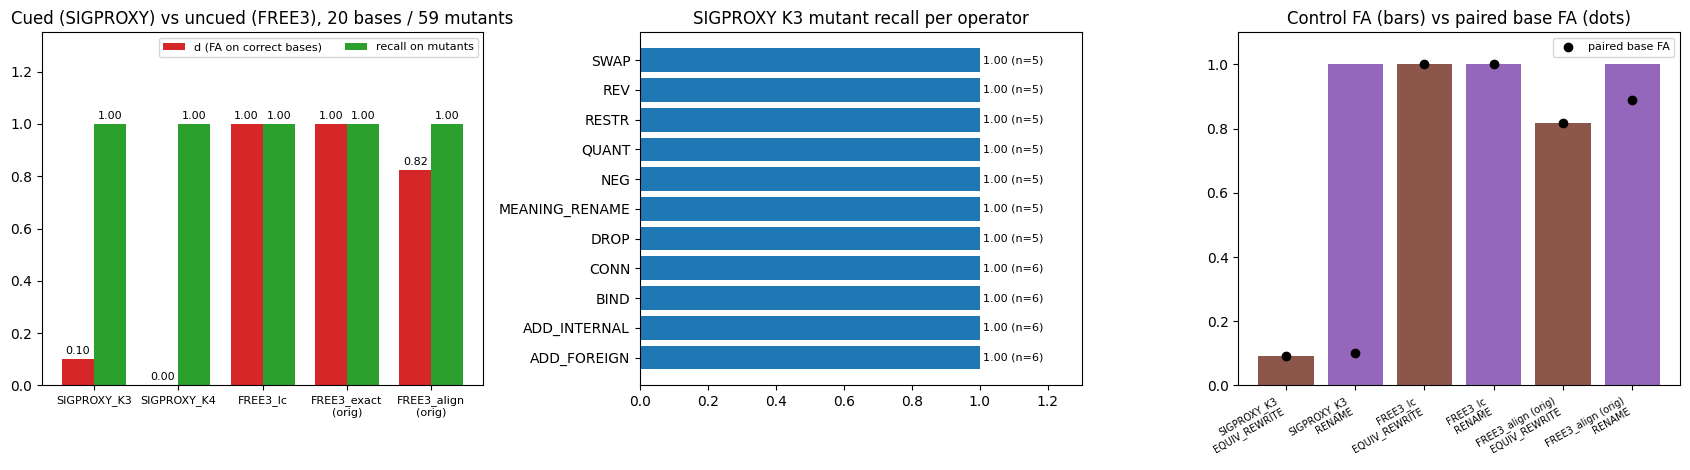

Per-operator recall (SIGPROXY_K3 vs uncued FREE3_lc):
variant         FREE3_lc  SIGPROXY_K3
op_label                             
ADD_FOREIGN          1.0          1.0
ADD_INTERNAL         1.0          1.0
ALL_MUTANTS          1.0          1.0
BIND                 1.0          1.0
CONN                 1.0          1.0
DROP                 1.0          1.0
MEANING_RENAME       1.0          1.0
NEG                  1.0          1.0
QUANT                1.0          1.0
RESTR                1.0          1.0
REV                  1.0          1.0
SWAP                 1.0          1.0

Full-run reference (results/tables.md): d = 0.149 cued vs 0.757 uncued FREE3-ALIGN on 74 long bases; recall 1.000 on 1,196 mutants; rename FA 1.000 under base-signature cue.


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

# (a) d on bases and mutant recall, cued vs uncued
order = ["SIGPROXY_K3", "SIGPROXY_K4", "FREE3_lc", "FREE3_exact (orig)", "FREE3_align (orig)"]
dvals = [bases[VARIANTS[v]].dropna().map(flag).mean() for v in order]
rvals = [part1[(part1.variant == v) & (part1.op_label == "ALL_MUTANTS")].recall_gt05.squeeze() for v in order]
x = np.arange(len(order)); w = 0.38
axes[0].bar(x - w / 2, dvals, w, label="d (FA on correct bases)", color="#d62728")
axes[0].bar(x + w / 2, rvals, w, label="recall on mutants", color="#2ca02c")
for i, (d_, r_) in enumerate(zip(dvals, rvals)):
    axes[0].text(i - w / 2, d_ + 0.02, f"{d_:.2f}", ha="center", fontsize=8)
    axes[0].text(i + w / 2, r_ + 0.02, f"{r_:.2f}", ha="center", fontsize=8)
axes[0].set_xticks(x, [o.replace(" (orig)", "\n(orig)") for o in order], fontsize=8)
axes[0].set_ylim(0, 1.35); axes[0].set_title(f"Cued (SIGPROXY) vs uncued (FREE3), {len(bases)} bases / {len(muts)} mutants")
axes[0].legend(fontsize=8, loc="upper right", ncol=2)

# (b) per-operator recall under SIGPROXY_K3
p = part1[(part1.variant == "SIGPROXY_K3") & (part1.op_label != "ALL_MUTANTS")].sort_values("op_label")
axes[1].barh(p.op_label, p.recall_gt05, color="#1f77b4")
for yy, (rv, n) in enumerate(zip(p.recall_gt05, p.n)):
    axes[1].text(min(rv, 1) + 0.01, yy, f"{rv:.2f} (n={n})", va="center", fontsize=8)
axes[1].set_xlim(0, 1.3); axes[1].set_title("SIGPROXY K3 mutant recall per operator")

# (c) controls
c2 = part2[part2.variant.isin(["SIGPROXY_K3", "FREE3_lc", "FREE3_align (orig)"])]
labels = [f"{r.variant}\n{r.control_type.replace('ALL_', '')}" for r in c2.itertuples()]
axes[2].bar(range(len(c2)), c2.FA_gt05, color=["#9467bd" if "RENAME" in l else "#8c564b" for l in labels])
axes[2].scatter(range(len(c2)), c2.paired_base_FA, color="k", zorder=3, label="paired base FA")
axes[2].set_xticks(range(len(c2)), labels, fontsize=7, rotation=30, ha="right")
axes[2].set_ylim(0, 1.1); axes[2].set_title("Control FA (bars) vs paired base FA (dots)"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

print("Per-operator recall (SIGPROXY_K3 vs uncued FREE3_lc):")
print(part1[part1.variant.isin(["SIGPROXY_K3", "FREE3_lc"])].pivot(index="op_label", columns="variant", values="recall_gt05").round(3).to_string())
print("\nFull-run reference (results/tables.md): d = 0.149 cued vs 0.757 uncued FREE3-ALIGN on 74 long bases; "
      "recall 1.000 on 1,196 mutants; rename FA 1.000 under base-signature cue.")